Epoch 1/200


/var/folders/0t/k860jmxx4d5__9h3p08nh77m0000gn/T/ipykernel_130/50079676.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.dropna(inplace=True)
/Users/dineshbisht/masterdegree/myproject_env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9972 - mae: 0.7886  
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9836 - mae: 0.7825
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9715 - mae: 0.7769
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9565 - mae: 0.7704
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9420 - mae: 0.7639
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9205 - mae: 0.7541
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8925 - mae: 0.7414
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8596 - mae: 0.7284
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8281 - mae: 0.7160
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8011 - mae: 0.7061
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7825 - mae: 0.6974
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7621 - mae: 0.6873
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7426 - mae:

/var/folders/0t/k860jmxx4d5__9h3p08nh77m0000gn/T/ipykernel_130/50079676.py:90: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction[j] = prediction[j-1] + predictionDiff[0][j-1] + slope
/var/folders/0t/k860jmxx4d5__9h3p08nh77m0000gn/T/ipykernel_130/50079676.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pred["SalesPred"] = prediction


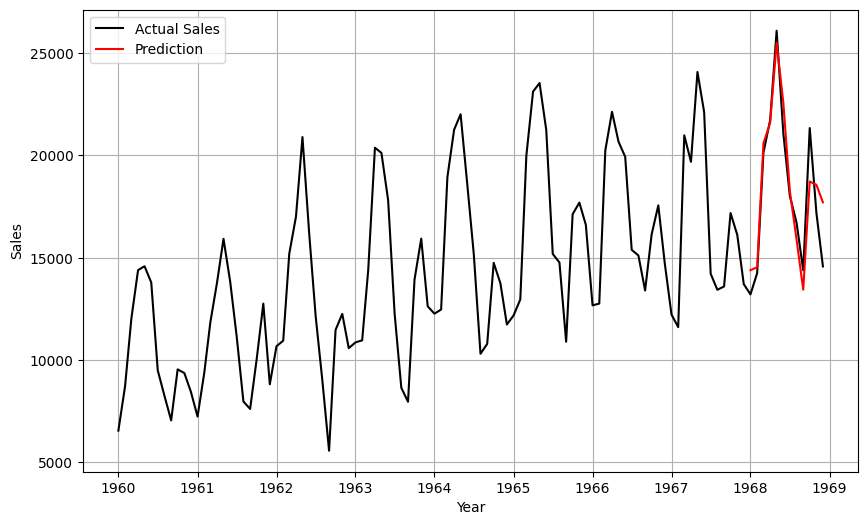

Mean absolute error in the test data: 1106.80


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import matplotlib.pyplot as plt

# Load monthly-car-sales.csv datatseet into pandas DataFrame
df = pd.read_csv("monthly-car-sales.csv")

# # Get basic information about data
# print(df.info())

df["Month"] = pd.to_datetime(df["Month"])
df["Time"] = df.index

seq_length = 12         # months
prediction_time = 12    # months

# Create a stationary time series
df["SalesLag"] = df["Sales"].shift(1)
df["SalesDiff"] = df.apply(lambda row:
    row["Sales"] - row["SalesLag"], axis=1)


for i in range(1, seq_length):
    df["SalesDiffLag" + str(i)] = df["SalesDiff"].shift(i)

for i in range(1, prediction_time + 1):
    df["SalesDiffFut" + str(i)] = df["SalesDiff"].shift(-i)

df_train = df.iloc[:-2*prediction_time]
df_train.dropna(inplace=True)
df_test = df.iloc[-2*prediction_time:]

# Define and Scale Variables
input_vars = ["SalesDiff"]
for i in range(1, seq_length):
    input_vars.append("SalesDiffLag" + str(i))

output_vars = []
for i in range(1, prediction_time + 1):
    output_vars.append("SalesDiffFut" + str(i))

scaler = StandardScaler()
scalero = StandardScaler()

X = np.array(df_train[input_vars])
X_scaled = scaler.fit_transform(X)
X_scaledLSTM = X_scaled.reshape(X.shape[0], X.shape[1], 1)
y = np.array(df_train[output_vars])
y_scaled = scalero.fit_transform(y)

X_test = np.array(df_test[input_vars])
X_testscaled = scaler.transform(X_test)
X_testscaledLSTM = X_testscaled.reshape(X_test.shape[0], X_test.shape[1], 1)

modelLR = LinearRegression()
XLR = np.array(df_train[["Time"]])
yLR = np.array(df_train[["Sales"]])
modelLR.fit(XLR, yLR)
slope = modelLR.coef_

modelLSTM = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, input_shape=(seq_length, 1),
                         return_sequences=False),
    tf.keras.layers.Dense(prediction_time)
])

modelLSTM.compile(
    tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

modelLSTM.fit(
    X_scaledLSTM,
    y_scaled, epochs=200, batch_size = seq_length
)

predictionDiff = scalero.inverse_transform(
    modelLSTM.predict(X_testscaledLSTM[prediction_time - 1].reshape(1, 12, 1))
)
prediction = np.zeros(13)
prediction[0] = df_test["Sales"].iloc[-1-prediction_time]
for i in range(1, 13):
    for j in range(1, 13):
        prediction[j] = prediction[j-1] + predictionDiff[0][j-1] + slope
prediction = np.array(prediction[1:])

df_pred = df_test[-12: ]
df_pred["SalesPred"] = prediction


plt.figure(figsize=(10, 6))
plt.plot(df["Month"].values, df["Sales"].values, color ="black", label="Actual Sales")
plt.plot(df_pred["Month"].values, df_pred["SalesPred"], color ="red", label="Prediction")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

print(f"Mean Absolute Error in the test data: {mean_absolute_error(df_pred["Sales"].values,  df_pred["SalesPred"]):.2f}")